# PhasemeterClient — quick start
This notebook shows how to use the `PhasemeterClient` class to connect,
configure, measure the phase difference (Δφ = φ₂ − φ₁), and sweep frequency
to plot Δφ as a function of frequency.

In [1]:
from phasemeter_client_fixed import PhasemeterClient


# Fill in the target of your Moku (e.g., '192.168.1.100' or link-local IPv6)
TARGET = '[fe80::7269:79ff:feb7:d15%6]'  # <-- replace if needed
client = PhasemeterClient(
    target=TARGET,
    phase_units='cycles',   # or 'deg' depending on API
    wrap_output=True,
    input_range='1Vpp',
    impedance='50Ohm',
    coupling='DC',
    pll_bandwidth='1kHz',
    poll_sec=0.5,
)
client.load(f0_hz=10e6)  # optional initial lock


## Change device settings on the fly

In [2]:
# Change front-end input range for channel 1, then both
client.set_frontend(1, input_range='1Vpp')
client.set_frontend(2, input_range='1Vpp')
# Change PLL bandwidth for both channels
client.set_bandwidth_all('1kHz')
# Move center frequency (both channels track the same f)
client.set_frequency_all(19e6)


## Read a single phase-difference sample

In [17]:
dphi_deg, frame = client.read_phase_difference_deg()
print('Δφ [deg]:', dphi_deg)
print('f1 [Hz]:', frame['ch1']['frequency'], 'f2 [Hz]:', frame['ch2']['frequency'])


Δφ [deg]: 6.72212541103363
f1 [Hz]: 19000011.05384952 f2 [Hz]: 19000011.05331839


# Laser Initialisation

In [ ]:
import TLX_5

laser=TLX_5.TRL_5()

port="COM4"

laser.connect(port)




Serial<id=0x193acefc460, open=True>(port='COM4', baudrate=115200, bytesize=8, parity='N', stopbits=1, timeout=1.0, xonxoff=False, rtscts=False, dsrdtr=False)

### Set Laser Wavelength

In [15]:
wl="1550.0"

laser.change_WL(wl)  # in nm

#laser.laser_ON()

In [16]:
laser.laser_OFF()

'1'

In [17]:
laser.laser_ON()

'1'

## Optional: Live Δφ vs. time (stop with **Kernel → Interrupt** or `Ctrl+C` in terminal)

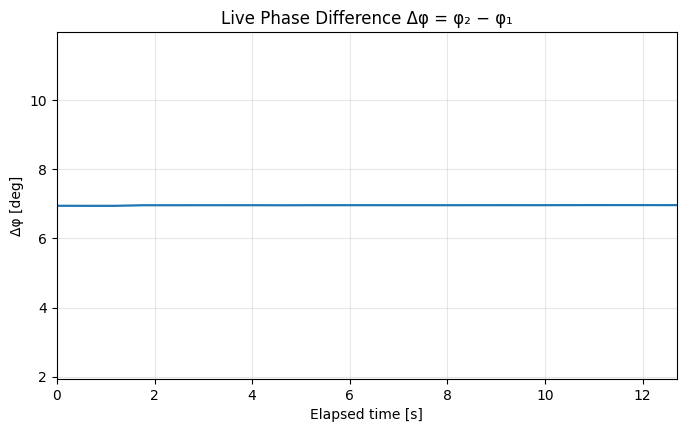


     12.7  5000003.0  5000003.0       6.965

Stopped by user.


In [18]:
client.live_plot_delta_phi_vs_time_jupyter(window_s=30, print_every_s=1.0)
# (commented out to avoid blocking in notebook)


## Δφ vs. frequency sweep

In [ ]:
import numpy as np
# Define a frequency list (both channels use the same frequency at each step)
freqs = np.linspace(5e6, 23e6, 20)  # 5–23 MHz, 17 points
sweep = client.sweep_phase_vs_frequency(
    freqs, settle_s=0.2, samples_per_point=5, average='median', reacquire_each_step=True
)
client.print_sweep(sweep)
client.plot_sweep(sweep, title='Δφ vs Frequency (both channels same f)')


## Clean up

In [ ]:
client.close()
